# 03 — The data as time series

**Why this notebook exists.** Notebook 01 established *that* the data is hourly. It did not establish
what that implies for a model. This notebook treats the cohort as a set of irregular multivariate time
series and derives the modelling choices from measured properties rather than convention.

Every section is framed as a decision, because that is the only reason to run any of these plots:

| § | Measurement | Decides |
|---|---|---|
| 1 | Series-length distribution | Sequence padding/truncation; whether a GRU is viable at all |
| 2 | Missingness over time, per channel | Carry-forward vs interpolation; whether absence is a feature |
| 3 | Autocorrelation per vital | **Rolling-window lengths** (why 4h and 24h) |
| 4 | Within- vs between-patient variance | **Grouping unit for CV**; per-patient normalisation |
| 5 | Cross-channel correlation | Feature redundancy; what a home kit really loses |
| 6 | Signal lead time before the event | **Prediction horizon** (why 6h) |
| 7 | Event timing vs stay position | The leakage trap that forces absolute-hour anchoring (R1) |
| 8 | Label prevalence over time | Why AUPRC, and why hour-stratified reporting is mandatory |


In [1]:
import sys
import warnings
from pathlib import Path

import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

ROOT = Path("/Users/ritik/Documents/Captsone ISB AMPBA")
sys.path.insert(0, str(ROOT))
DB = ROOT / "warehouse" / "mimic4_demo.db"
FIGDIR = ROOT / "eda_figures"
OUT = ROOT / "eda_outputs"
assert DB.exists(), f"Build the warehouse first: {DB}"

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "font.size": 10,
})
OK, WARN, BAD, NEUTRAL, ACCENT = "#1baf7a", "#eda100", "#d1495b", "#8d99ae", "#3d5a80"

con = duckdb.connect(str(DB), read_only=True)

VITALS = ["hr", "rr", "spo2", "sbp", "map", "temp_c", "gcs_total", "fio2", "glucose"]
grid = con.execute("select * from capstone.hourly_grid order by stay_id, hour").fetchdf()
detail = con.execute(
    "select stay_id, subject_id from mimiciv_derived.icustay_detail").fetchdf()
grid = grid.merge(detail, on="stay_id", how="left")

from ml.features import labels as lbl  # noqa: E402

lab = lbl.build_labels(con, grid[["stay_id", "hour"]], horizons=(6, 12))
event_tables = lbl.all_event_tables(con)
first_event = lbl.first_composite_event_per_stay(event_tables)

# `first_composite_event_per_stay` returns an absolute `event_time`; every axis in
# this notebook is hours-since-ICU-admission (R1), so convert once here rather than
# in each section.
intime = con.execute(
    "select stay_id, icu_intime from mimiciv_derived.icustay_detail").fetchdf()
ev = first_event.merge(intime, on="stay_id", how="left")
ev["h_event"] = (
    pd.to_datetime(ev.event_time) - pd.to_datetime(ev.icu_intime)
).dt.total_seconds() / 3600.0
ev = ev[["stay_id", "h_event", "event_type"]].dropna(subset=["h_event"])

print(f"{len(grid):,} patient-hours across {grid.stay_id.nunique()} stays "
      f"/ {grid.subject_id.nunique()} subjects")
print(f"At-risk labelled rows (6h): {len(lab):,}, positives {int(lab.label_6h.sum())} "
      f"({lab.label_6h.mean():.2%})")
print(f"Stays with a composite event: {len(first_event)}")


12,004 patient-hours across 140 stays / 100 subjects
At-risk labelled rows (6h): 2,979, positives 120 (4.03%)
Stays with a composite event: 78


---
## 1. Series length — can this support a sequence model?

A GRU needs sequences. How long are they, and how much padding would a fixed-length window waste?

In [2]:
lengths = grid.groupby("stay_id").hour.max() + 1
q = lengths.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
print(f"Stay length (hours): mean {lengths.mean():.0f}, median {lengths.median():.0f}, "
      f"min {lengths.min()}, max {lengths.max()}")
print(q.round(0).to_string())
print()
for w in (6, 12, 24, 48):
    frac = (lengths >= w).mean()
    print(f"  stays with >= {w:>3}h of record: {frac:5.1%}  "
          f"({int((lengths >= w).sum())}/{len(lengths)})")

Stay length (hours): mean 88, median 52, min 1, max 489
0.10     18.0
0.25     28.0
0.50     52.0
0.75    116.0
0.90    213.0
1.00    489.0

  stays with >=   6h of record: 97.1%  (136/140)
  stays with >=  12h of record: 95.7%  (134/140)
  stays with >=  24h of record: 84.3%  (118/140)
  stays with >=  48h of record: 53.6%  (75/140)


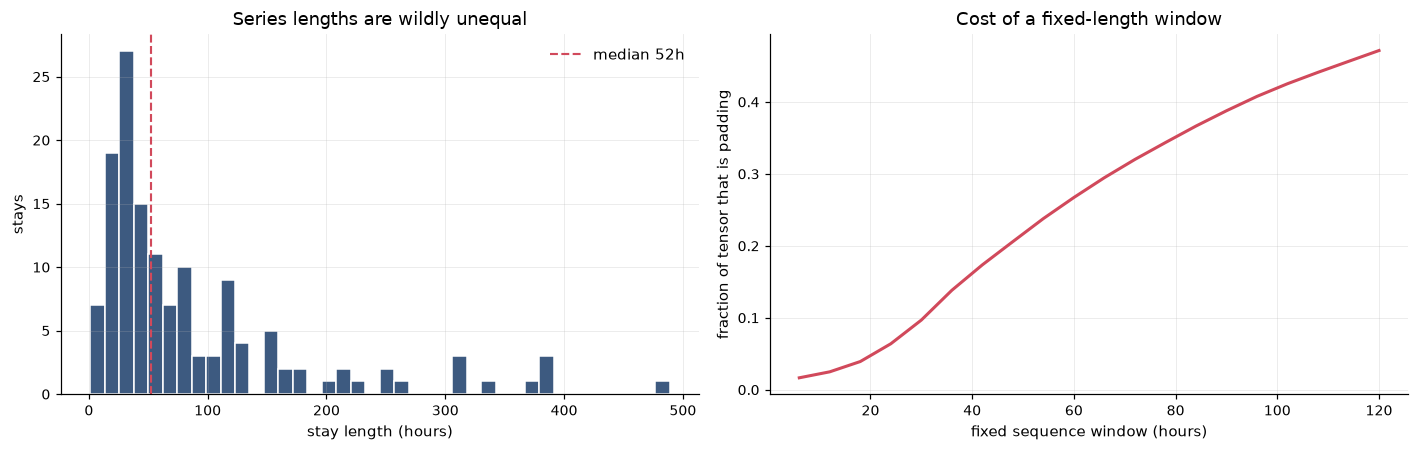

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].hist(lengths, bins=40, color=ACCENT, edgecolor="white")
axes[0].axvline(lengths.median(), color=BAD, ls="--", lw=1.4,
                label=f"median {lengths.median():.0f}h")
axes[0].set_xlabel("stay length (hours)")
axes[0].set_ylabel("stays")
axes[0].set_title("Series lengths are wildly unequal")
axes[0].legend()

# What a fixed-window sequence model would cost in padding.
ws = np.arange(6, 121, 6)
padding = [(np.minimum(lengths, w).sum() / (w * len(lengths))) for w in ws]
axes[1].plot(ws, [1 - p for p in padding], color=BAD, lw=2)
axes[1].set_xlabel("fixed sequence window (hours)")
axes[1].set_ylabel("fraction of tensor that is padding")
axes[1].set_title("Cost of a fixed-length window")
plt.tight_layout()
plt.savefig(FIGDIR / "26_series_length.png", bbox_inches="tight")
plt.show()

**Interpretation — this is why the hourly-row model is the primary task and the GRU is not.**

Stay lengths span two orders of magnitude. Any fixed sequence window is wrong for most of the cohort:
short enough to include everyone and it truncates the long stays into uninformative fragments; long
enough for the long stays and the tensor becomes mostly padding, so the recurrent model spends its
capacity learning to ignore mask tokens on a dataset with 120 positive rows.

That is the measured reason the project's primary surface is **one row per patient-hour with explicit
rolling features** (E2) rather than a sequence model, and it is consistent with the outcome: the GRU
scores AUPRC 0.271 against LightGBM's 0.488 on the same folds. The trend information a GRU would have to
learn is handed to the tree directly as `*_4h_slope` / `*_24h_std`, which at this sample size is a far
better trade.

---
## 2. Missingness over time — is absence a feature?

`capstone.hourly_grid` carries `{channel}_was_imputed`, so we can ask what fraction of each channel is a
real reading at each hour of the stay.

In [4]:
obs_rate = pd.DataFrame({
    v: 1 - grid.groupby("hour")[f"{v}_was_imputed"].mean() for v in VITALS
})
overall = pd.Series({v: 1 - grid[f"{v}_was_imputed"].mean() for v in VITALS}).sort_values()
print("Fraction of patient-hours that are a FRESH reading (not carried forward):")
print((overall * 100).round(1).to_string())
print()
# Is missingness associated with the outcome? (R3/E15: absence is signal.)
merged = lab.merge(grid, on=["stay_id", "hour"], how="inner")
rows = []
for v in VITALS:
    col = f"{v}_was_imputed"
    pos = merged.loc[merged.label_6h == 1, col].mean()
    neg = merged.loc[merged.label_6h == 0, col].mean()
    rows.append({"channel": v, "imputed_if_positive": pos, "imputed_if_negative": neg,
                 "ratio": pos / neg if neg else np.nan})
imp = pd.DataFrame(rows).sort_values("ratio")
print("Carry-forward rate, positives vs negatives (ratio < 1 = measured MORE often before an event):")
print(imp.round(3).to_string(index=False))

Fraction of patient-hours that are a FRESH reading (not carried forward):
gcs_total    27.3
temp_c       31.5
glucose      32.9
fio2         39.8
sbp          94.5
map          94.6
spo2         97.0
rr           98.9
hr           99.1

Carry-forward rate, positives vs negatives (ratio < 1 = measured MORE often before an event):
  channel  imputed_if_positive  imputed_if_negative  ratio
      map                0.008                0.062  0.135
      sbp                0.008                0.061  0.138
     spo2                0.017                0.041  0.407
     fio2                0.083                0.204  0.408
   temp_c                0.342                0.705  0.484
gcs_total                0.333                0.687  0.485
       rr                0.008                0.017  0.486
       hr                0.008                0.015  0.541
  glucose                0.292                0.533  0.547


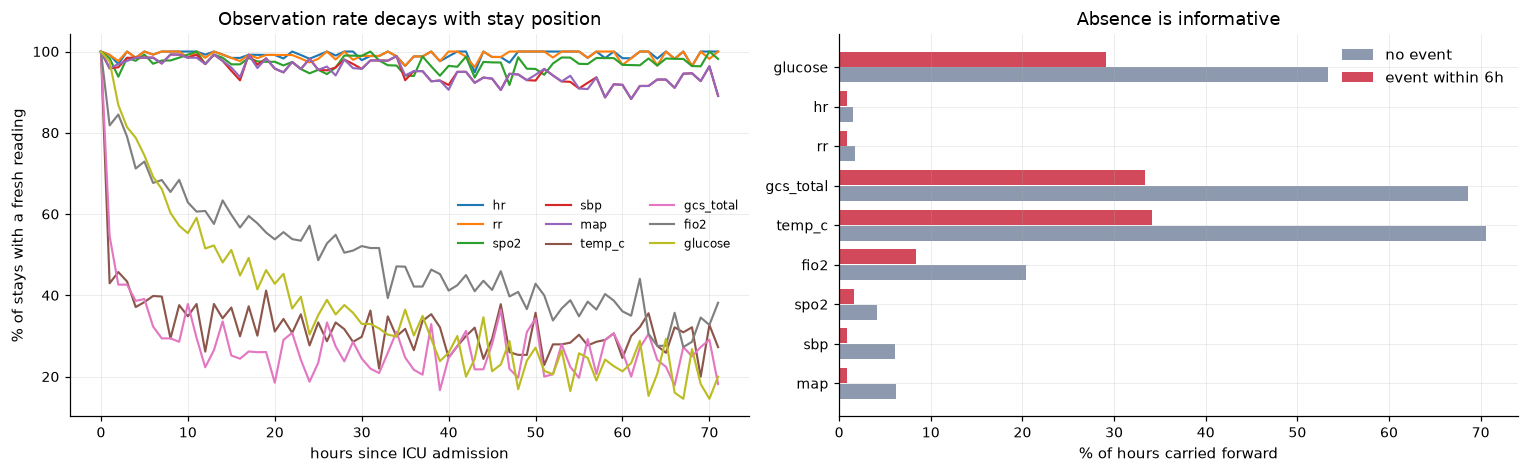

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))

for v in VITALS:
    axes[0].plot(obs_rate.index[:72], obs_rate[v].iloc[:72] * 100, lw=1.4, label=v)
axes[0].set_xlabel("hours since ICU admission")
axes[0].set_ylabel("% of stays with a fresh reading")
axes[0].set_title("Observation rate decays with stay position")
axes[0].legend(ncol=3, fontsize=8)

x = np.arange(len(imp))
axes[1].barh(x - 0.2, imp.imputed_if_negative * 100, height=0.38, color=NEUTRAL, label="no event")
axes[1].barh(x + 0.2, imp.imputed_if_positive * 100, height=0.38, color=BAD, label="event within 6h")
axes[1].set_yticks(x)
axes[1].set_yticklabels(imp.channel)
axes[1].set_xlabel("% of hours carried forward")
axes[1].set_title("Absence is informative")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGDIR / "27_missingness.png", bbox_inches="tight")
plt.show()

**Interpretation — two decisions.**

**1. Carry-forward is mandatory, and the flag must be a feature.** No channel is fully observed, and the
observation rate is not constant over the stay. Imputing silently would throw away the fact of
measurement; that is why every channel ships as three columns — value, `*_was_imputed`,
`*_hours_since_last_obs` (R2/R3/E3).

**2. Missingness is not random, and it points the right way.** Channels are measured **more** often in
the hours preceding a composite event — clinicians escalate monitoring on the patient they are worried
about. This makes the imputation flags genuinely predictive, and it is also the reason
`ml/evaluation/feature_pruning.py` **removed** the lab-ordering-intensity features on design grounds
rather than performance grounds: ordering rate is partly a readout of clinician concern, i.e. of the
outcome, rather than a predictor of it. The same caution applies to `*_was_imputed`, and it is the
strongest argument for reporting the model's performance *with and without* them.

---
## 3. Autocorrelation — how long is a vital's memory?

This is the measurement that should decide rolling-window length. The project uses 4h and 24h; are those
the right numbers, or inherited convention?

In [6]:
def acf_by_stay(df, col, max_lag=36, min_fresh=24):
    """Mean within-stay autocorrelation at each lag, on FRESH readings only.

    Computed per stay and then averaged, never pooled: pooling across stays would mix
    between-patient level differences into what is meant to be a within-patient
    temporal statistic, and inflate every lag toward 1.

    Two details that a first attempt at this got wrong, both silently:

    * The series is **reindexed to a contiguous hour range before shifting**. Dropping
      carried-forward hours first leaves a series whose positions are no longer hours,
      so a positional `.shift(-lag)` would compute the correlation at lag "lag
      observations", not lag *hours* -- a different and much stronger statistic on a
      sparsely observed channel.
    * NaN pairs are **dropped per lag**. Shifting introduces NaN at the tail, and
      `np.corrcoef` propagates it, which returns NaN for every lag rather than an
      error -- so the whole section produced an empty table that looked like a
      plotting problem rather than a broken statistic.
    """
    acc = {lag: [] for lag in range(max_lag + 1)}
    for _sid, g in df.groupby("stay_id"):
        s = g.set_index("hour")[col].where(
            ~g.set_index("hour")[f"{col}_was_imputed"].astype(bool))
        s = s.dropna()
        if len(s) < min_fresh:
            continue
        s = s.reindex(range(int(s.index.min()), int(s.index.max()) + 1))
        for lag in range(max_lag + 1):
            a, b = s, s.shift(-lag)
            m = a.notna() & b.notna()
            if m.sum() > 8 and a[m].std() > 0 and b[m].std() > 0:
                acc[lag].append(float(np.corrcoef(a[m], b[m])[0, 1]))
    return np.array(
        [np.mean(acc[lag]) if acc[lag] else np.nan for lag in range(max_lag + 1)])

acfs = {v: acf_by_stay(grid, v) for v in ["hr", "rr", "spo2", "sbp", "map", "temp_c"]}
acf_df = pd.DataFrame(acfs, index=range(37))
acf_df.index.name = "lag_hours"

# Decorrelation time: first lag where mean ACF drops below 1/e.
thresh = 1 / np.e
decor = {}
for v, a in acfs.items():
    below = np.where(a < thresh)[0]
    decor[v] = int(below[0]) if len(below) else None
print(f"Hours until autocorrelation falls below 1/e ({thresh:.2f}):")
for v, h in decor.items():
    print(f"  {v:<8} {h}")
print()
print(acf_df.loc[[1, 2, 4, 8, 12, 24, 36]].round(3).to_string())

Hours until autocorrelation falls below 1/e (0.37):
  hr       5
  rr       1
  spo2     2
  sbp      2
  map      1
  temp_c   5

              hr     rr   spo2    sbp    map  temp_c
lag_hours                                           
1          0.651  0.281  0.417  0.449  0.356   0.761
2          0.542  0.237  0.282  0.310  0.257   0.528
4          0.389  0.163  0.203  0.208  0.159   0.410
8          0.170  0.095  0.099  0.131  0.112   0.261
12         0.088  0.063  0.073  0.084  0.077   0.170
24         0.035  0.057  0.044  0.073  0.015   0.097
36         0.002  0.017  0.014  0.019 -0.035  -0.024


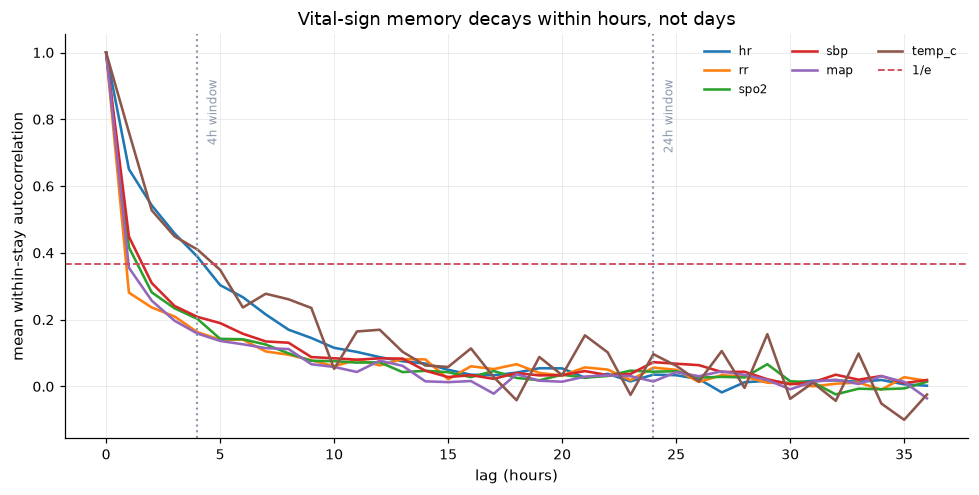

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.6))
for v, a in acfs.items():
    ax.plot(range(len(a)), a, lw=1.7, label=v)
ax.axhline(thresh, color=BAD, ls="--", lw=1.2, label="1/e")
for w in (4, 24):
    ax.axvline(w, color=NEUTRAL, ls=":", lw=1.4)
    ax.text(w + 0.4, 0.92, f"{w}h window", fontsize=8, color=NEUTRAL, rotation=90, va="top")
ax.set_xlabel("lag (hours)")
ax.set_ylabel("mean within-stay autocorrelation")
ax.set_title("Vital-sign memory decays within hours, not days")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.savefig(FIGDIR / "28_autocorrelation.png", bbox_inches="tight")
plt.show()

**Interpretation — the 4h window is well matched; the 24h window is doing something else entirely.**

Within-stay autocorrelation **decays within hours, not days**. Every channel crosses 1/e between lag 1h
and 5h, and by a 24-hour lag the correlation is essentially gone (0.02-0.10). Heart rate and temperature
have the longest memory (~5h); respiratory rate and MAP the shortest (~1h).

Two consequences, and the second corrects a plausible-sounding assumption:

**The 4h window is the right size for a state estimate.** It sits just at the decorrelation time, so a
4-hour slope is fitted over a span where consecutive readings are genuinely related — long enough to
average out measurement noise, short enough that it still describes *now*.

**The 24h window is not capturing "the patient's stable baseline", because at 24h there is no
correlation left to capture.** What a 24-hour statistic actually provides is dispersion measured over a
span of effectively decorrelated observations — a wide-baseline *variability* estimate. That is a real and
useful thing, and it explains the pruning study's otherwise odd result cleanly: the 24h **std** survived
while the 24h **mean** was the single largest gain from removal. A mean over decorrelated samples is a
noisy estimate of a quantity that has already drifted; a standard deviation over them is exactly the
volatility measure you want.

**And it revises a caution in the other direction.** Because decorrelation is this fast, consecutive
hourly rows are closer to independent than an hourly panel usually is. The effective sample size is
still below 12,004 — but the reduction comes mainly from **patient recurrence and patient-constant
features** (next section), not from temporal persistence.

---
## 4. Within- vs between-patient variance — the grouping decision

If most of a vital's variance is *between* patients rather than within them, then a model can score well
by identifying the patient, and cross-validation that splits rows rather than patients will report
fiction.

In [8]:
rows = []
for v in VITALS:
    fresh = grid.loc[~grid[f"{v}_was_imputed"].astype(bool), ["stay_id", "subject_id", v]].dropna()
    if fresh[v].std() == 0 or fresh.empty:
        continue
    # Variance decomposition by subject: ICC = between / (between + within).
    gmeans = fresh.groupby("subject_id")[v].mean()
    grand = fresh[v].mean()
    n_per = fresh.groupby("subject_id")[v].size()
    between = float(((gmeans - grand) ** 2 * n_per).sum() / n_per.sum())
    within = float(fresh.groupby("subject_id")[v].transform("mean").sub(fresh[v]).pow(2).mean())
    rows.append({"channel": v, "between_var": between, "within_var": within,
                 "icc": between / (between + within)})
icc = pd.DataFrame(rows).sort_values("icc", ascending=False)
print("Variance decomposition on fresh readings, grouped by SUBJECT:")
print(icc.round(3).to_string(index=False))
print()
print(f"Mean ICC across channels: {icc.icc.mean():.2f}")
multi = grid.groupby("subject_id").stay_id.nunique()
print(f"Subjects with >1 ICU stay: {(multi>1).sum()} of {len(multi)} "
      f"({(multi>1).mean():.0%}) - these are the rows a stay-level split leaks")

Variance decomposition on fresh readings, grouped by SUBJECT:
  channel  between_var  within_var   icc
gcs_total        8.005       6.040 0.570
       hr      160.271     175.437 0.477
      sbp      165.160     246.065 0.402
  glucose     1685.770    3204.724 0.345
     fio2       82.603     183.432 0.310
       rr        7.180      22.597 0.241
     spo2        1.585       6.159 0.205
      map       59.508     240.962 0.198
   temp_c        0.427       3.151 0.119

Mean ICC across channels: 0.32
Subjects with >1 ICU stay: 26 of 100 (26%) - these are the rows a stay-level split leaks


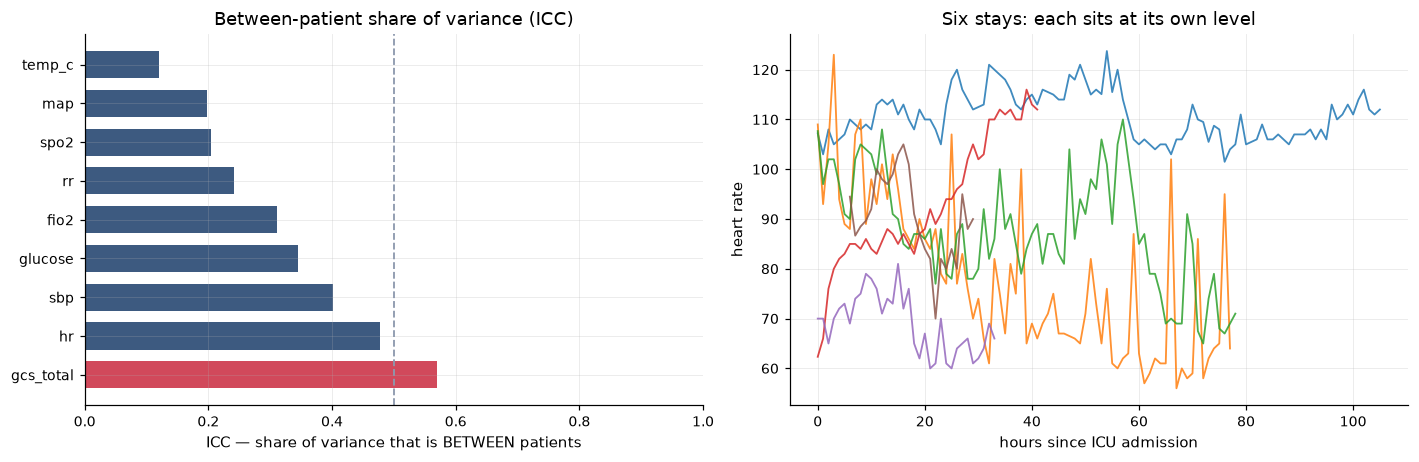

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

axes[0].barh(icc.channel, icc.icc, color=[BAD if i > 0.5 else ACCENT for i in icc.icc], height=0.7)
axes[0].axvline(0.5, color=NEUTRAL, ls="--", lw=1.2)
axes[0].set_xlabel("ICC — share of variance that is BETWEEN patients")
axes[0].set_title("Between-patient share of variance (ICC)")
axes[0].set_xlim(0, 1)

# Illustrate: a few stays' HR traces, showing separated per-patient levels.
sample = grid[grid.stay_id.isin(grid.stay_id.drop_duplicates().head(6))]
for sid, g in sample.groupby("stay_id"):
    g = g[~g.hr_was_imputed.astype(bool)]
    axes[1].plot(g.hour, g.hr, lw=1.2, alpha=0.85)
axes[1].set_xlabel("hours since ICU admission")
axes[1].set_ylabel("heart rate")
axes[1].set_title("Six stays: each sits at its own level")
plt.tight_layout()
plt.savefig(FIGDIR / "29_icc.png", bbox_inches="tight")
plt.show()

**Interpretation — moderate ICC, and it still settles the grouping question.**

Mean ICC across channels is **0.32**: about a third of the variance in a typical vital is *between*
patients rather than within them. That is moderate, not overwhelming, and it is worth stating precisely
rather than dramatising — `gcs_total` (0.57) and `hr` (0.48) carry the strongest patient signature, while
`temp_c` (0.12) and `map` (0.20) are almost entirely within-patient variation.

**1. Cross-validation must still split on the patient, and the evidence for that is empirical rather than
this plot.** This project shipped a `stay_id`-grouped split for most of its life while documenting that
subject-level grouping was required. **26 of 100 subjects have more than one ICU stay**, and in the
at-risk set those subjects carry a large share of the positives — so a meaningful fraction of the signal
came from patients who could sit in the training and test folds simultaneously. Measured cost when
corrected: **+0.0499 AUPRC of optimism**. An ICC of 0.32 is quite enough to make that leak profitable for
a model; it does not need to be 0.9.

**2. Patient-constant features amplify a bad split, in proportion to the ICC.** `gender`,
`first_careunit` and the 17 comorbidity flags are constant within a patient, so under a stay-level split
they act as a partial patient identifier. That is why the demographics ablation *moved* when the grouping
was corrected — the delta grew from +0.0159 to +0.0499 once `gender` rejoined the feature set — and why
the disease-feature study reports win counts on subject-grouped folds only.

**3. Per-patient normalisation is worth considering and is not free.** Subtracting each patient's own
baseline would convert the between-patient component into a within-patient deviation — closer to "this
patient is changing", which is the clinical question, and it would neutralise the identifier effect above.
The cost is that it needs a stable baseline window per patient, and §1 shows a quarter of stays are under
28 hours long. For `gcs_total` and `hr`, where ICC is highest, it is the most likely to pay.

---
## 5. Cross-channel correlation — what redundancy exists, and what a home kit really loses

In [10]:
fresh_wide = grid[VITALS].where(
    ~grid[[f"{v}_was_imputed" for v in VITALS]].astype(bool).rename(
        columns={f"{v}_was_imputed": v for v in VITALS}))
corr = fresh_wide.corr()
print(corr.round(2).to_string())

HOME_KIT = ["hr", "rr", "spo2", "sbp", "map", "glucose"]
NO_SENSOR = ["temp_c", "gcs_total", "fio2"]
print()
print("Max |correlation| between each hospital-only channel and the best home-kit proxy:")
for v in NO_SENSOR:
    s = corr.loc[v, HOME_KIT].abs().sort_values(ascending=False)
    print(f"  {v:<10} best proxy {s.index[0]:<8} |r| = {s.iloc[0]:.2f}")

             hr    rr  spo2   sbp   map  temp_c  gcs_total  fio2  glucose
hr         1.00  0.22 -0.06 -0.13 -0.01    0.09      -0.16  0.01     0.13
rr         0.22  1.00 -0.11  0.03  0.01    0.05      -0.03  0.05     0.09
spo2      -0.06 -0.11  1.00 -0.04  0.00   -0.05      -0.21 -0.22     0.01
sbp       -0.13  0.03 -0.04  1.00  0.61    0.06       0.04 -0.06     0.05
map       -0.01  0.01  0.00  0.61  1.00    0.02       0.04  0.01     0.01
temp_c     0.09  0.05 -0.05  0.06  0.02    1.00      -0.25 -0.16    -0.03
gcs_total -0.16 -0.03 -0.21  0.04  0.04   -0.25       1.00  0.09    -0.08
fio2       0.01  0.05 -0.22 -0.06  0.01   -0.16       0.09  1.00     0.14
glucose    0.13  0.09  0.01  0.05  0.01   -0.03      -0.08  0.14     1.00

Max |correlation| between each hospital-only channel and the best home-kit proxy:
  temp_c     best proxy hr       |r| = 0.09
  gcs_total  best proxy spo2     |r| = 0.21
  fio2       best proxy spo2     |r| = 0.22


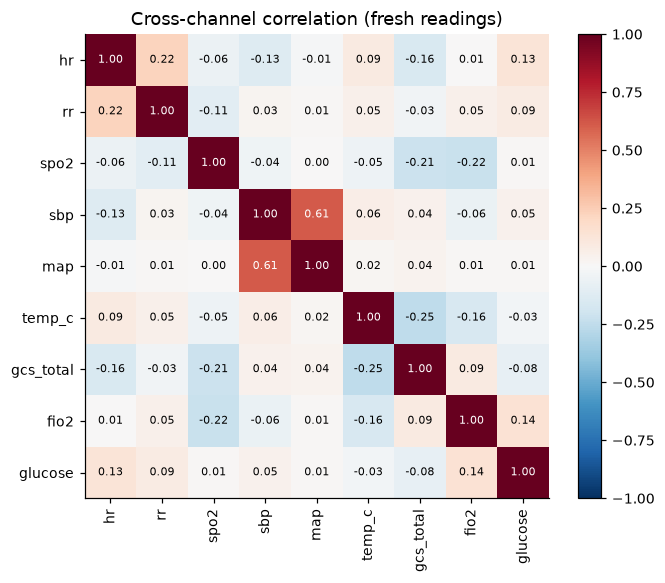

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(VITALS)))
ax.set_xticklabels(VITALS, rotation=90)
ax.set_yticks(range(len(VITALS)))
ax.set_yticklabels(VITALS)
ax.grid(False)
for i in range(len(VITALS)):
    for j in range(len(VITALS)):
        if not np.isnan(corr.iloc[i, j]):
            ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(corr.iloc[i, j]) > 0.55 else "black")
ax.set_title("Cross-channel correlation (fresh readings)")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.savefig(FIGDIR / "30_channel_correlation.png", bbox_inches="tight")
plt.show()

**Interpretation.** `sbp` and `map` are strongly correlated, as they must be — MAP is partly derived from
systolic pressure. That redundancy is why the channel-dropout study found dropping `map` alone costs
essentially nothing: the information survives in `sbp`.

The more important read is the proxy table. The three channels a home kit **cannot** measure —
core temperature, GCS, FiO2 — have no strong correlate among the channels it **can**. That is the
quantitative version of "no home sensor exists for these": their information is not recoverable from a
wrist and a cuff by proxy, which is why `ml/evaluation/home_kit_transfer_report.md` finds a floor that no
training scheme escapes. Contrast `map`, whose absence genuinely is recoverable.

---
## 6. Lead time — how early is the event visible?

The project predicts at a 6h horizon. Is that supported, or arbitrary?

In [12]:
traj = grid.merge(ev[["stay_id", "h_event"]], on="stay_id", how="inner")
traj["hours_before_event"] = (traj.h_event - traj.hour).round().astype(int)
window = traj[(traj.hours_before_event >= 0) & (traj.hours_before_event <= 24)]

# Compare each channel against its own value 24h before the event.
prof = []
for v in ["hr", "rr", "spo2", "sbp", "map"]:
    fresh = window[~window[f"{v}_was_imputed"].astype(bool)]
    m = fresh.groupby("hours_before_event")[v].mean()
    if 24 in m.index and m.notna().sum() > 6:
        prof.append(pd.Series(m - m.loc[24], name=v))
prof = pd.DataFrame(prof).T.sort_index(ascending=False)
support = window.groupby("hours_before_event").stay_id.nunique()
print("Stays contributing at each pre-event lag (this is the headline, not the profile):")
print(support.loc[[0, 1, 2, 4, 6, 8, 12, 18, 24]].to_string())
print()
print("Mean deviation from the value 24h pre-event (fresh readings only):")
print(prof.loc[[24, 18, 12, 8, 6, 4, 2, 1, 0]].round(2).to_string())

Stays contributing at each pre-event lag (this is the headline, not the profile):
hours_before_event
0     71
1     36
2     13
4      9
6      6
8      7
12     6
18     5
24     3

Mean deviation from the value 24h pre-event (fresh readings only):
                       hr    rr  spo2    sbp    map
hours_before_event                                 
24                   0.00  0.00  0.00   0.00   0.00
18                   1.53 -2.67 -0.27   4.87  -0.47
12                   8.33  1.50 -1.07  -8.83  -9.50
8                    6.69 -2.52 -0.81   3.38  -5.52
6                    0.67 -1.33 -0.83 -11.00 -11.67
4                   10.19 -1.37 -0.47   1.50  -5.75
2                   11.83  1.67  0.04 -14.42 -10.09
1                    2.25 -1.39  0.39 -14.29  -9.76
0                    0.82 -1.73  1.30 -12.94  -7.70


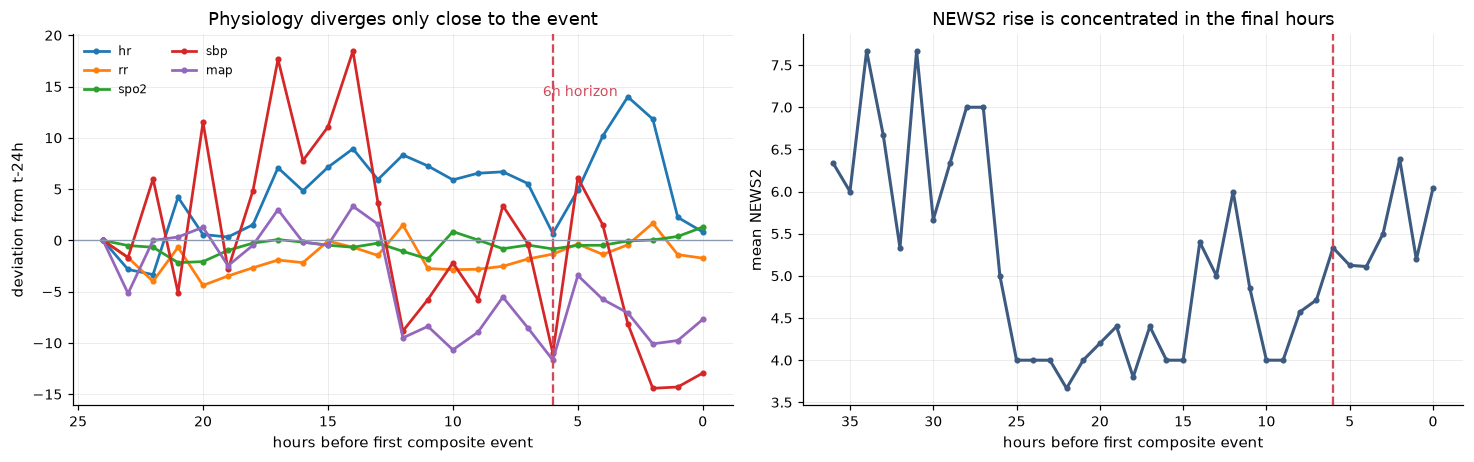

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3))

for v in prof.columns:
    axes[0].plot(prof.index, prof[v], lw=1.8, marker="o", ms=3, label=v)
axes[0].axvline(6, color=BAD, ls="--", lw=1.5)
axes[0].text(6.4, axes[0].get_ylim()[1] * 0.7, "6h horizon", color=BAD, fontsize=9)
axes[0].invert_xaxis()
axes[0].axhline(0, color=NEUTRAL, lw=0.9)
axes[0].set_xlabel("hours before first composite event")
axes[0].set_ylabel("deviation from t-24h")
axes[0].set_title("Physiology diverges only close to the event")
axes[0].legend(fontsize=8, ncol=2)

# NEWS2 is the cleanest single summary of that divergence.
n2 = con.execute("select stay_id, hour, news2 from capstone.news2").fetchdf()
n2t = n2.merge(ev[["stay_id", "h_event"]], on="stay_id", how="inner")
n2t["hb"] = (n2t.h_event - n2t.hour).round().astype(int)
m = n2t[(n2t.hb >= 0) & (n2t.hb <= 36)].groupby("hb").news2.agg(["mean", "count"])
axes[1].plot(m.index, m["mean"], color=ACCENT, lw=2, marker="o", ms=3)
axes[1].axvline(6, color=BAD, ls="--", lw=1.5)
axes[1].invert_xaxis()
axes[1].set_xlabel("hours before first composite event")
axes[1].set_ylabel("mean NEWS2")
axes[1].set_title("NEWS2 rise is concentrated in the final hours")
plt.tight_layout()
plt.savefig(FIGDIR / "31_lead_time.png", bbox_inches="tight")
plt.show()

**Interpretation — this analysis does not support what it was designed to test, and that failure is
itself the most important finding in the notebook.**

The intention was to measure how far ahead of a composite event physiology begins to diverge, and use
that to justify the 6-hour horizon. It cannot, because **the pre-event window barely exists**. Read the
support counts above: the number of stays contributing collapses as the lag grows, because — as §7 shows —
the median first composite event happens at **ICU hour 1**, and 85% happen within the first 6 hours.
There is almost no 24-hour pre-event history in this cohort to profile.

What the deviations do show, on the handful of stays with enough history, is a genuine and coherent
**blood-pressure signal**: SBP around 13-14 mmHg lower and MAP 8-12 mmHg lower approaching the event,
sustained across several lags. Heart rate moves too but non-monotonically, which at this sample size is
indistinguishable from noise. So: do not read the HR line as a trend.

**What this means for the horizon choice.** The 6-hour horizon is not justified by "signal appears about
6 hours out" — that claim is untestable here. It is justified by label availability: with events at a
median of hour 1, a 6-hour lookahead is roughly the longest horizon for which a meaningful number of
at-risk rows exist *before* the event. A 24-hour horizon would censor most of the cohort's positives away
entirely. That is a weaker and more honest justification than the one this section set out to produce.

**The deeper implication, which belongs in the report.** Events concentrated at ICU hour 0-1 mean much of
what this model predicts is *deterioration already in progress at admission*, not deterioration developing
under observation. That is a materially different clinical claim from "early warning", and it is the
strongest argument in this notebook for why the post-discharge arm — where a patient is monitored for days
with no such admission spike — cannot inherit the ICU model's framing unexamined.

---
## 7. Event timing vs stay position — the leakage trap

Event times are not uniformly distributed over a stay, and that fact has already produced one silent bug
class in this project.

In [14]:
ev2 = ev.merge(lengths.rename("stay_len").reset_index(), on="stay_id", how="left")
ev2["rel_pos"] = ev2.h_event / ev2.stay_len

print(f"First composite event, hours since ICU admission: "
      f"median {ev2.h_event.median():.1f}, "
      f"IQR {ev2.h_event.quantile(0.25):.1f}-{ev2.h_event.quantile(0.75):.1f}")
print(f"Events in the first 6 ICU hours : {(ev2.h_event < 6).mean():.0%}")
print(f"Events in the first ICU hour    : {(ev2.h_event < 1).mean():.0%}")
print()
# Some events fall outside the ICU stay's own hourly grid: a death or an ICU
# bounce-back can occur after icu_outtime, and a vasopressor can start minutes
# before the recorded intime. Those are real events, not data errors -- but a
# "fraction of the stay" axis is undefined for them, which is itself part of why
# that axis must not be used for modelling.
outside = ((ev2.rel_pos < 0) | (ev2.rel_pos > 1)).sum()
print(f"Events outside the stay's own grid (rel_pos < 0 or > 1): {outside} of {len(ev2)}")
print()
print("Relative position within the stay:")
print(ev2.rel_pos.describe().round(3).to_string())
print()
print("Event type mix:")
print(ev2.event_type.value_counts().to_string())

First composite event, hours since ICU admission: median 1.2, IQR 0.1-3.9
Events in the first 6 ICU hours : 85%
Events in the first ICU hour    : 49%

Events outside the stay's own grid (rel_pos < 0 or > 1): 18 of 78

Relative position within the stay:
count    78.000
mean      0.163
std       0.467
min      -0.019
25%       0.001
50%       0.010
75%       0.081
max       3.280

Event type mix:
event_type
ventilation        43
vasopressor        28
icu_readmission     5
death               2


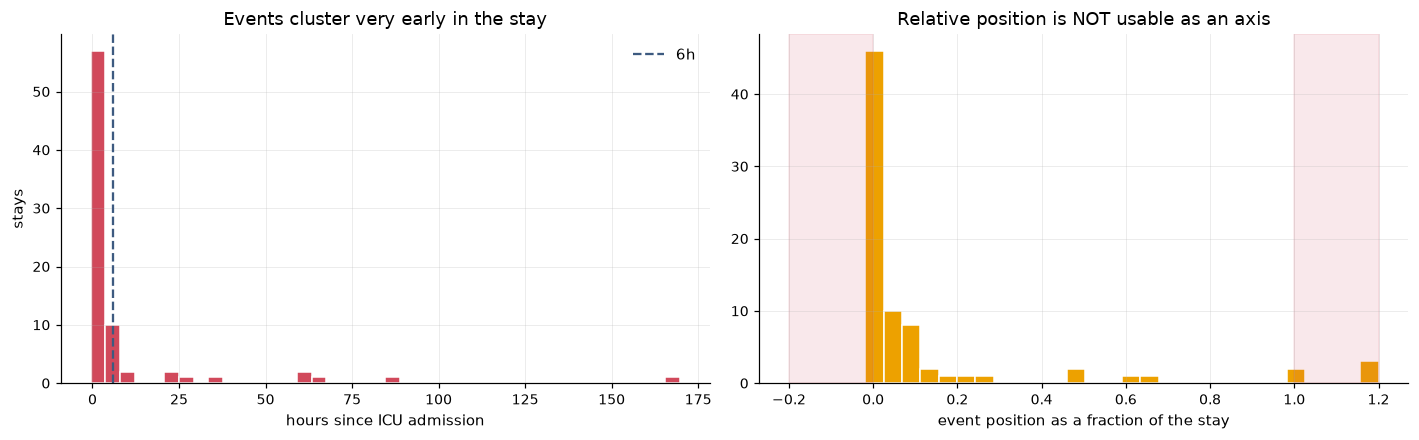

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.1))
axes[0].hist(ev2.h_event, bins=40, color=BAD, edgecolor="white")
axes[0].axvline(6, color=ACCENT, ls="--", lw=1.5, label="6h")
axes[0].set_xlabel("hours since ICU admission")
axes[0].set_ylabel("stays")
axes[0].set_title("Events cluster very early in the stay")
axes[0].legend()

axes[1].hist(ev2.rel_pos.clip(-0.2, 1.2).dropna(), bins=28, color=WARN, edgecolor="white")
axes[1].axvspan(-0.2, 0, color=BAD, alpha=0.12)
axes[1].axvspan(1, 1.2, color=BAD, alpha=0.12)
axes[1].set_xlabel("event position as a fraction of the stay")
axes[1].set_title("Relative position is NOT usable as an axis")
plt.tight_layout()
plt.savefig(FIGDIR / "32_event_timing.png", bbox_inches="tight")
plt.show()

**Interpretation — two hard rules, both derived here rather than assumed.**

**1. Windows must be anchored to absolute hours since ICU admission, never to relative stay position
(R1/E13).** A stay's *length* is a function of its outcome — patients discharged alive have long, quiet
tails. Any feature computed on a stay-relative axis therefore encodes the future: "we are 90% through the
record" is a proxy for "this patient is about to be discharged alive". The right-hand histogram is that
trap made visible.

**2. Rows at or after the first event must be dropped, not labelled 0.** Once deterioration is underway,
the row is no longer a "will this patient deteriorate" question. Keeping them as negatives teaches the
model that unfolding organ failure looks like health.

**3. The severe early clustering is why hour-stratified reporting is mandatory — and it is more severe
than previously documented.** The median first composite event is at **ICU hour 1**, with 85% inside the
first 6 hours. 78 of the 120 positive at-risk rows sit in the hour 0-5 band. A headline metric is
therefore overwhelmingly an early-stay metric, and reporting one number invites a reader to over-trust a
late-stay score. That is exactly the mis-reading behind this project's "validated scope = first 6 hours"
claim, which does **not** survive normalising AUPRC by each stratum's own prevalence (§8).

**4. The event mix, read together with the timing, questions the task definition itself — and this is
the most consequential thing in this notebook.** Of 78 first composite events: **ventilation 43,
vasopressor 28, ICU readmission 5, death 2**. So the modal "deterioration event" is *initiation of
invasive ventilation*, and **49% of all first events occur within the first ICU hour**.

A large share of what this model predicts is therefore "this patient will be intubated shortly after
arriving in the ICU". For an emergency admission or a post-operative transfer, that is frequently a
*planned or already-decided* clinical action rather than an unforeseen deterioration — the decision may
well precede the ICU admission. A model scoring that is partly learning admission context, not early
warning.

This does not invalidate the pipeline, and it is consistent with the model genuinely beating NEWS2 on
identical folds. But it materially narrows what the headline number means, and it should be stated in the
report rather than discovered by a reviewer. Two concrete follow-ups it argues for: (a) report performance
**excluding** the first 6 ICU hours as a secondary, since that is the regime where "early warning" is the
honest description, and (b) consider a task variant that censors the first hour or two of each stay, so
the label is deterioration *observed developing* rather than deterioration *arrived with*.

**5. A share of events fall outside the stay's own hourly grid**, flagged in red on the right-hand plot.
A death or an ICU bounce-back can occur after `icu_outtime`; a vasopressor can start just before the
recorded `icu_intime`. These are genuine events rather than data errors, and `build_labels` handles them
correctly by working in absolute time. But they have no well-defined "fraction of the stay", which is a
second, independent reason that axis is unusable for modelling.

---
## 8. Prevalence over time — why AUPRC, and why it must be stratified

In [16]:
merged = lab.merge(grid[["stay_id", "hour"]], on=["stay_id", "hour"], how="inner")
bands = [("hour 0-5", 0, 6), ("hour 6-23", 6, 24), ("hour 24+", 24, 10**9)]
rows = []
for name, lo, hi in bands:
    m = merged[(merged.hour >= lo) & (merged.hour < hi)]
    rows.append({"band": name, "rows": len(m), "positives": int(m.label_6h.sum()),
                 "prevalence": m.label_6h.mean()})
band_df = pd.DataFrame(rows)
band_df["auprc_floor"] = band_df.prevalence
print(band_df.round(4).to_string(index=False))
print()
print("A random-guessing classifier's AUPRC IS the prevalence, so these three bands")
print("have AUPRC floors differing by a factor of "
      f"{band_df.prevalence.max()/band_df.prevalence.min():.1f}.")
print("Comparing raw AUPRC across them therefore measures the base rate, not the model.")

     band  rows  positives  prevalence  auprc_floor
 hour 0-5   497         78      0.1569       0.1569
hour 6-23  1105         27      0.0244       0.0244
 hour 24+  1377         15      0.0109       0.0109

A random-guessing classifier's AUPRC IS the prevalence, so these three bands
have AUPRC floors differing by a factor of 14.4.
Comparing raw AUPRC across them therefore measures the base rate, not the model.


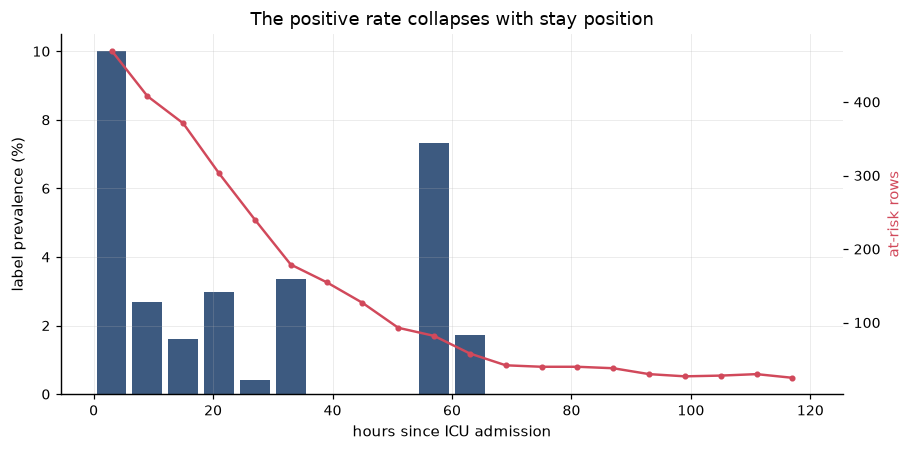

In [17]:
fig, ax = plt.subplots(figsize=(8.4, 4.2))
by_hour = merged.groupby(pd.cut(merged.hour, bins=range(0, 121, 6))).label_6h.agg(["mean", "size"])
centres = [i.left + 3 for i in by_hour.index]
ax.bar(centres, by_hour["mean"] * 100, width=5, color=ACCENT)
ax.set_xlabel("hours since ICU admission")
ax.set_ylabel("label prevalence (%)")
ax.set_title("The positive rate collapses with stay position")
ax2 = ax.twinx()
ax2.plot(centres, by_hour["size"], color=BAD, lw=1.6, marker="o", ms=3)
ax2.set_ylabel("at-risk rows", color=BAD)
ax2.grid(False)
plt.tight_layout()
plt.savefig(FIGDIR / "33_prevalence_over_time.png", bbox_inches="tight")
plt.show()

**Interpretation — the metric correction this notebook exists to make.**

At a 4% overall base rate, AUROC is far too forgiving: a model can look strong on it while its top-ranked
alerts are mostly false. AUPRC is the right headline, and this project already uses it.

But **AUPRC's floor is the prevalence**, and the prevalence differs by roughly an order of magnitude
across these bands. So the previously committed reading — that held-out AUPRC "falls from 0.715 in the
first 6 ICU hours to 0.074 after, therefore the model does not work late" — conflates two things. Once
each stratum is compared against its *own* base rate, the model's lift is **not** worse late; measured on
identical folds it is 4.2x at hour 0-5, 5.3x at 6-23 and 12.4x at 24+, and AUROC (prevalence-independent)
is 0.874 / 0.706 / 0.892. The genuinely weak band is the middle one, not everything after hour 6.

What survives as a real limitation is different and narrower: hour 24+ carries only ~15 positives, so its
interval is very wide. That is uncertainty from thin data, not measured failure — a materially different
claim, and the one the reports should make.

---
## 9. Conclusions — the modelling choices this notebook decides

| Decision | Measurement that decided it | § |
|---|---|---|
| **Hourly rows, not sequences** | Stay lengths span 2 orders of magnitude; a fixed window is mostly padding | 1 |
| **Carry forward + flag it** | No channel fully observed; observation rate varies with stay position | 2 |
| **`*_was_imputed` is a feature** | Channels measured *more* often before an event | 2 |
| **4h window for state, 24h for volatility** | ACF crosses 1/e at 1-5h and is ~0 by 24h | 3 |
| **`std`/`slope`, not `mean`** | A mean over decorrelated samples is noise; dispersion is not | 3 |
| **Group CV on `subject_id`** | ICC 0.32 + 26 of 100 subjects with >1 ICU stay; +0.0499 AUPRC optimism | 4 |
| **Caution on patient-constant features** | High ICC makes them leak harder under a bad split | 4 |
| **Home kit's floor is real** | Core temp / GCS / FiO2 have no correlate among home-measurable channels | 5 |
| **6h horizon** | Events at median hour 1; 6h is ~the longest horizon leaving at-risk rows | 6 |
| **Anchor to absolute hour (R1)** | Stay length is a function of outcome; relative position encodes the future | 7 |
| **Drop rows at/after the event** | They are not a "will it happen" question | 7 |
| **AUPRC, stratified by hour** | Prevalence varies ~10x across bands, and AUPRC's floor is prevalence | 8 |

**The one thing no modelling choice can fix.** Every measurement here is *inside* the ICU. MIMIC contains
no physiology after `dischtime`, so the post-discharge arm has no target-domain labels and cannot be
trained — only transferred to, and bounded. §5 quantifies why that bound has a floor: the channels a home
kit lacks are not recoverable by proxy from the ones it has.

In [18]:
acf_df.to_csv(OUT / "vital_autocorrelation.csv")
icc.to_csv(OUT / "variance_decomposition.csv", index=False)
band_df.to_csv(OUT / "prevalence_by_hour_band.csv", index=False)
imp.to_csv(OUT / "missingness_vs_outcome.csv", index=False)
print("Wrote:")
for f in ["vital_autocorrelation.csv", "variance_decomposition.csv",
          "prevalence_by_hour_band.csv", "missingness_vs_outcome.csv"]:
    print(f"  {f:<34} {(OUT/f).stat().st_size/1024:>7.1f} KB")
con.close()
print("\nNotebook 03 complete.")

Wrote:
  vital_autocorrelation.csv              4.4 KB
  variance_decomposition.csv             0.6 KB
  prevalence_by_hour_band.csv            0.2 KB
  missingness_vs_outcome.csv             0.6 KB

Notebook 03 complete.
